In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


Loading MNIST dataset...


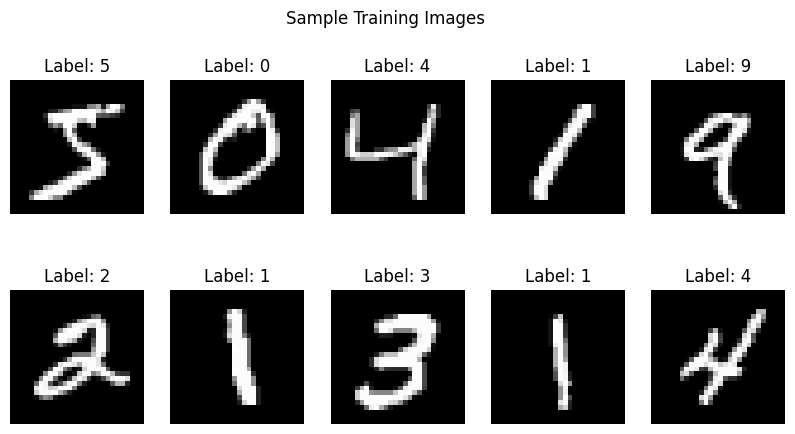

Training set shape: (60000, 784)
Test set shape: (10000, 784)


In [8]:
# --- 1. Load & Preprocess Data ---

# Load MNIST
print("Loading MNIST dataset...")
(X_tr_img, y_tr), (X_te_img, y_te) = mnist.load_data()

# Visualize some samples
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_tr_img[i], cmap='gray')
    plt.title(f"Label: {y_tr[i]}")
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.show()

# Flatten images: (28,28) -> (784,)
X_tr_flat = X_tr_img.reshape(-1, 784).astype(np.float32)
X_te_flat = X_te_img.reshape(-1, 784).astype(np.float32)

# Scale pixels: 0-255 -> 0-1
X_tr_flat = X_tr_flat / 255.0
X_te_flat = X_te_flat / 255.0

print(f"Training set shape: {X_tr_flat.shape}")
print(f"Test set shape: {X_te_flat.shape}")

Training Gaussian Naive Bayes...
=== Gaussian Naive Bayes ===
Accuracy: 0.5558

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.89      0.84       980
           1       0.85      0.95      0.90      1135
           2       0.90      0.26      0.40      1032
           3       0.71      0.35      0.47      1010
           4       0.88      0.17      0.29       982
           5       0.55      0.05      0.09       892
           6       0.65      0.93      0.77       958
           7       0.88      0.27      0.42      1028
           8       0.28      0.67      0.40       974
           9       0.37      0.95      0.53      1009

    accuracy                           0.56     10000
   macro avg       0.69      0.55      0.51     10000
weighted avg       0.69      0.56      0.52     10000



<Figure size 800x600 with 0 Axes>

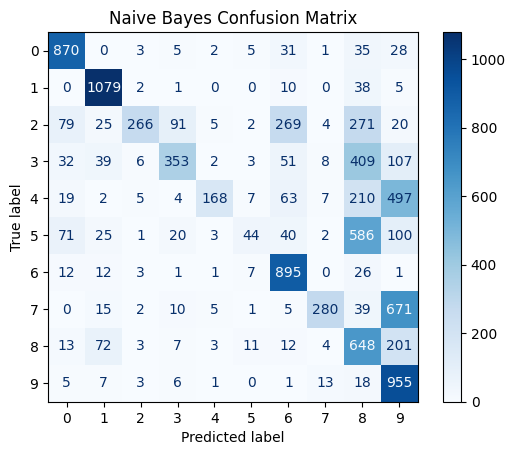

In [9]:
# --- 2. Model: Naive Bayes ---

print("Training Gaussian Naive Bayes...")
nb = GaussianNB()
nb.fit(X_tr_flat, y_tr)

nb_pred = nb.predict(X_te_flat)
acc_nb = accuracy_score(y_te, nb_pred)

print("=== Gaussian Naive Bayes ===")
print("Accuracy:", acc_nb)
print("\nClassification Report:\n", classification_report(y_te, nb_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_te, nb_pred, cmap='Blues', values_format='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Training Decision Tree (Subset for speed)...
=== Decision Tree (Entropy) - Subset ===
Accuracy: 0.8212

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89       460
           1       0.93      0.95      0.94       571
           2       0.80      0.82      0.81       530
           3       0.77      0.81      0.79       500
           4       0.78      0.80      0.79       500
           5       0.80      0.76      0.78       456
           6       0.83      0.79      0.81       462
           7       0.88      0.86      0.87       512
           8       0.78      0.72      0.75       489
           9       0.79      0.76      0.77       520

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.82      0.82      0.82      5000



<Figure size 800x600 with 0 Axes>

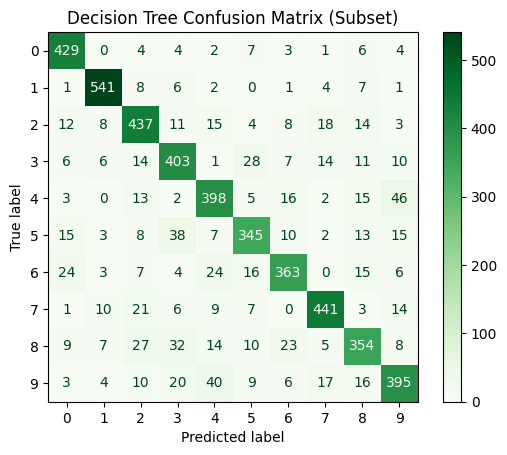

In [10]:
# --- 3. Model: Decision Tree ---

print("Training Decision Tree (Subset for speed)...")

# Use subset for speed as per requirement
n_train_sub = 20000
n_test_sub  = 5000

dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=25,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_tr_flat[:n_train_sub], y_tr[:n_train_sub])
dt_pred = dt.predict(X_te_flat[:n_test_sub])
acc_dt = accuracy_score(y_te[:n_test_sub], dt_pred)

print("=== Decision Tree (Entropy) - Subset ===")
print("Accuracy:", acc_dt)
print("\nClassification Report:\n", classification_report(y_te[:n_test_sub], dt_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_te[:n_test_sub], dt_pred, cmap='Greens', values_format='d')
plt.title("Decision Tree Confusion Matrix (Subset)")
plt.show()

Training MLP Classifier...
=== ANN (MLPClassifier) ===
Accuracy: 0.9758

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.97       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.95      0.97      1028
           8       0.95      0.98      0.96       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



<Figure size 800x600 with 0 Axes>

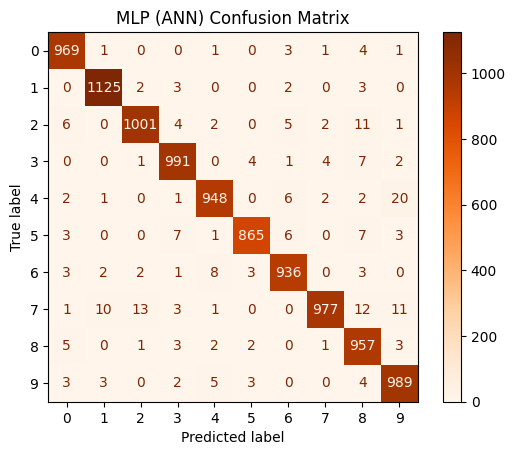

In [11]:
# --- 4. Model: MLP Classifier (ANN) ---

print("Training MLP Classifier...")

# Parameters as requested
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=20,
    random_state=42
)

ann.fit(X_tr_flat, y_tr)
ann_pred = ann.predict(X_te_flat)
acc_ann = accuracy_score(y_te, ann_pred)

print("=== ANN (MLPClassifier) ===")
print("Accuracy:", acc_ann)
print("\nClassification Report:\n", classification_report(y_te, ann_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_te, ann_pred, cmap='Oranges', values_format='d')
plt.title("MLP (ANN) Confusion Matrix")
plt.show()

Visualizing Sample Predictions from MLP Model...


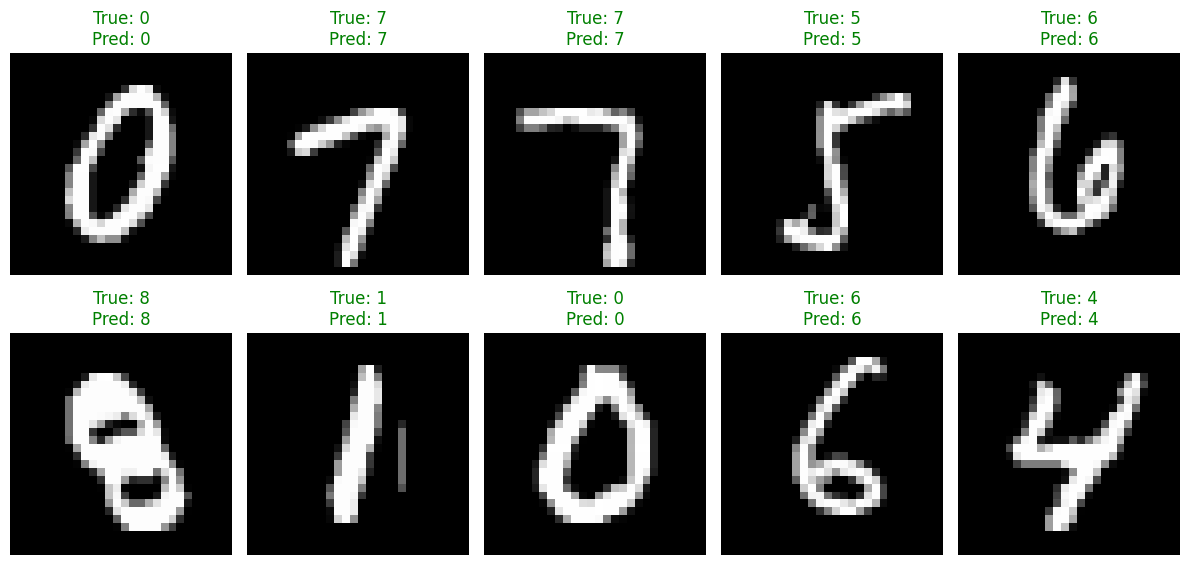

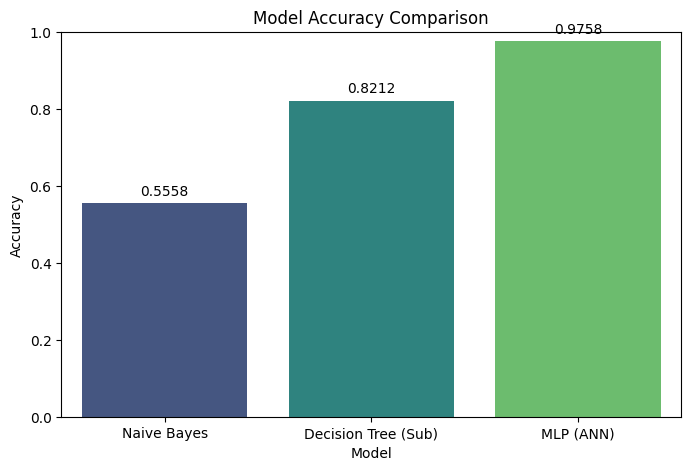

In [12]:
# --- 5. Visualizing Predictions ---

print("Visualizing Sample Predictions from MLP Model...")
plt.figure(figsize=(12, 6))
indices = np.random.choice(len(X_te_flat), 10, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    img = X_te_img[idx]
    true_label = y_te[idx]
    pred_label = ann.predict([X_te_flat[idx]])[0]
    
    plt.imshow(img, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Accuracy Comparison
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree (Sub)', 'MLP (ANN)'],
    'Accuracy': [acc_nb, acc_dt, acc_ann]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylim(0.0, 1.0)
for index, row in results.iterrows():
    plt.text(index, row.Accuracy + 0.02, f"{row.Accuracy:.4f}", color='black', ha="center")
plt.show()